# UPI App Decline Analysis
## Notebook 03 - Visualisation
---
**What this notebook does (and ONLY this):**
- Loads the 9 CSV files from `sql_results/`
- Creates one seaborn chart per SQL query result
- Saves every chart as a PNG to `charts/`
- Exports Tableau-ready CSVs to `tableau_exports/`

**What this notebook does NOT do:** No SQL. No database connection. No new analysis.

---
**Folder structure required:**
```
your_project/
├── 03_visualisation.ipynb
├── sql_results/       <- 9 CSVs from Notebook 02
├── charts/            <- created automatically
└── tableau_exports/   <- created automatically
```


## Step 1 - Imports and Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('charts', exist_ok=True)
os.makedirs('tableau_exports', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi':        130,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

APP_COLORS = {
    'Paytm':   '#2a78d6',
    'GPay':    '#eda100',
    'PhonePe': '#4a3aa7',
}

CAT_COLORS = {
    'Technical Failures':       '#e34948',
    'Payment Failures':         '#eda100',
    'Customer Support':         '#2a78d6',
    'Trust & Security':         '#4a3aa7',
    'UX Problems':              '#1baf7a',
    'Regulatory Issues':        '#e87ba4',
    'General Dissatisfaction':  '#b0b0b0',
    'Other':                    '#b0b0b0',
}

ERA_LABELS = {
    '1_Early (2018-2019)':    'Early\n2018-19',
    '2_Crisis (2020-2022)':   'Crisis\n2020-22',
    '3_Recovery (2023-2026)': 'Recovery\n2023-26',
}

print('Setup complete')
print(f'  matplotlib : {plt.matplotlib.__version__}')
print(f'  seaborn    : {sns.__version__}')

Setup complete
  matplotlib : 3.10.0
  seaborn    : 0.13.2


## Step 2 - Load All SQL Result CSVs
Load all 9 result files from `sql_results/`.
Quick shape check to confirm everything loaded correctly.


In [2]:
R = 'sql_results'

q1  = pd.read_csv(f'{R}/q1_ratings_overview_result1.csv')
q2  = pd.read_csv(f'{R}/q2_ratings_trend_result1.csv')
q3  = pd.read_csv(f'{R}/q3_complaint_categories_result1.csv')
q4  = pd.read_csv(f'{R}/q4_paytm_deepdive_result1.csv')
q5a = pd.read_csv(f'{R}/q5_response_analysis_result1.csv')
q5b = pd.read_csv(f'{R}/q5_response_analysis_result2.csv')
q6a = pd.read_csv(f'{R}/q6_era_comparison_result1.csv')
q6b = pd.read_csv(f'{R}/q6_era_comparison_result2.csv')
q6c = pd.read_csv(f'{R}/q6_era_comparison_result3.csv')

# Relabel Other as General Dissatisfaction throughout
for df in [q3, q6b]:
    df['complaint_category'] = df['complaint_category'].replace(
        {'Other': 'General Dissatisfaction'}
    )

datasets = {
    'Q1  Ratings Overview':     q1,
    'Q2  Year Trend':           q2,
    'Q3  Complaint Categories': q3,
    'Q4  Paytm Deep Dive':      q4,
    'Q5a Response Overview':    q5a,
    'Q5b Response by Year':     q5b,
    'Q6a Era Sentiment':        q6a,
    'Q6b Era Complaints':       q6b,
    'Q6c Executive Summary':    q6c,
}

print('=== DATA LOADED ===')
for name, df in datasets.items():
    print(f'  {name:30s}  {len(df):>3} rows x {len(df.columns)} cols')

# Verify Q6c has no Other
print()
print('Q6c top complaints (should have no Other):')
print(q6c[['app','era','top_complaint']].to_string(index=False))

=== DATA LOADED ===
  Q1  Ratings Overview              3 rows x 8 cols
  Q2  Year Trend                   21 rows x 7 cols
  Q3  Complaint Categories         21 rows x 5 cols
  Q4  Paytm Deep Dive             120 rows x 11 cols
  Q5a Response Overview             3 rows x 12 cols
  Q5b Response by Year             18 rows x 6 cols
  Q6a Era Sentiment                 9 rows x 10 cols
  Q6b Era Complaints               63 rows x 6 cols
  Q6c Executive Summary             9 rows x 5 cols

Q6c top complaints (should have no Other):
    app                    era      top_complaint
   GPay    1_Early (2018-2019)   Payment Failures
   GPay   2_Crisis (2020-2022) Technical Failures
   GPay 3_Recovery (2023-2026) Technical Failures
  Paytm    1_Early (2018-2019) Technical Failures
  Paytm   2_Crisis (2020-2022) Technical Failures
  Paytm 3_Recovery (2023-2026) Technical Failures
PhonePe    1_Early (2018-2019)   Payment Failures
PhonePe   2_Crisis (2020-2022)   Payment Failures
PhonePe 3_Recov

## Step 3 - Chart 1: Ratings Overview
**From:** Q1  
**Chart:** Horizontal bar - avg rating + negative % side by side  
**Insight:** GPay worst at 56.9% negative despite being a Google product


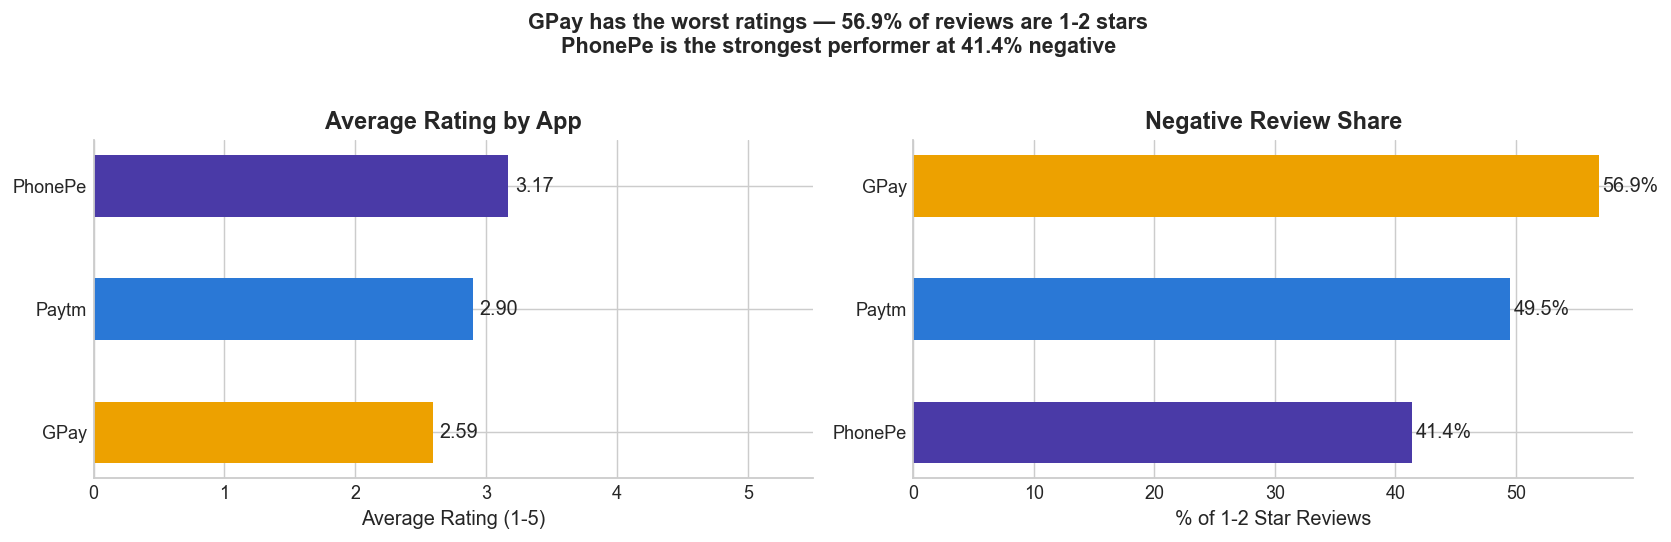

Saved: charts/chart1_ratings_overview.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

q1_sorted = q1.sort_values('avg_rating', ascending=True)
colors = [APP_COLORS[a] for a in q1_sorted['app']]

bars = axes[0].barh(
    q1_sorted['app'], q1_sorted['avg_rating'],
    color=colors, height=0.5
)
axes[0].set_xlim(0, 5.5)
axes[0].set_xlabel('Average Rating (1-5)')
axes[0].set_title('Average Rating by App')
for bar, val in zip(bars, q1_sorted['avg_rating']):
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}', va='center', fontsize=11
    )

q1_neg = q1.sort_values('negative_pct', ascending=True)
colors_neg = [APP_COLORS[a] for a in q1_neg['app']]
bars2 = axes[1].barh(
    q1_neg['app'], q1_neg['negative_pct'],
    color=colors_neg, height=0.5
)
axes[1].set_xlabel('% of 1-2 Star Reviews')
axes[1].set_title('Negative Review Share')
for bar, val in zip(bars2, q1_neg['negative_pct']):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%', va='center', fontsize=11
    )

fig.suptitle(
    'GPay has the worst ratings — 56.9% of reviews are 1-2 stars\n'
    'PhonePe is the strongest performer at 41.4% negative',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('charts/chart1_ratings_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: charts/chart1_ratings_overview.png')

## Step 4 - Chart 2: Rating Trend by Year
**From:** Q2  
**Chart:** Line chart with shaded crisis period  
**Insight:** All apps bottomed 2020-2022, massive jump in 2023


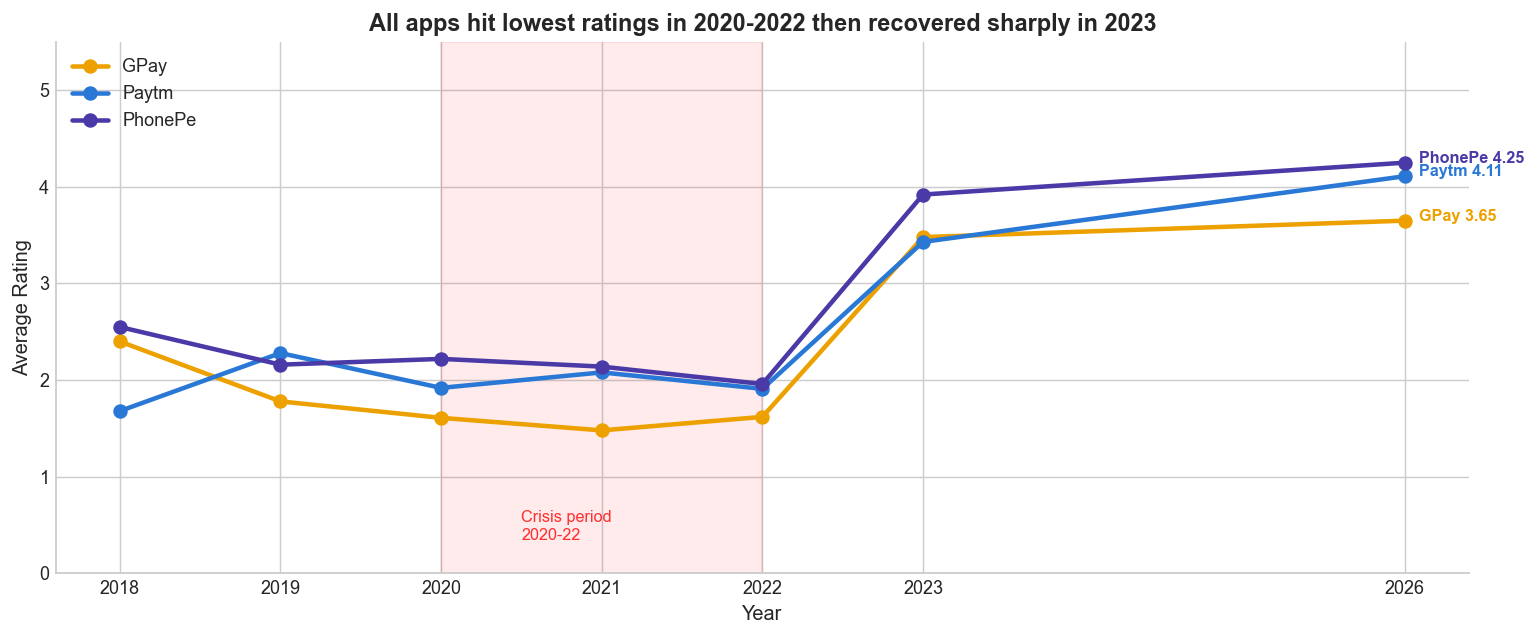

Saved: charts/chart2_rating_trend.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

for app in ['GPay', 'Paytm', 'PhonePe']:
    df_app = q2[q2['app'] == app].sort_values('year')
    ax.plot(
        df_app['year'], df_app['avg_rating'],
        marker='o', linewidth=2.5, markersize=7,
        color=APP_COLORS[app], label=app
    )
    last = df_app.iloc[-1]
    ax.annotate(
        f"{app} {last['avg_rating']:.2f}",
        xy=(last['year'], last['avg_rating']),
        xytext=(8, 0), textcoords='offset points',
        fontsize=9, color=APP_COLORS[app], fontweight='bold'
    )

ax.axvspan(2020, 2022, alpha=0.08, color='red')
ax.text(2020.5, 0.35, 'Crisis period\n2020-22',
        fontsize=9, color='red', alpha=0.8)

ax.set_xlabel('Year')
ax.set_ylabel('Average Rating')
ax.set_ylim(0, 5.5)
ax.set_xticks(sorted(q2['year'].unique()))
ax.set_title(
    'All apps hit lowest ratings in 2020-2022 then recovered sharply in 2023'
)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('charts/chart2_rating_trend.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: charts/chart2_rating_trend.png')

## Step 5 - Chart 3: Complaint Categories
**From:** Q3  
**Chart:** Side by side horizontal bars per app  
**Insight:** Paytm has 20x more regulatory complaints than GPay  
**Note:** General Dissatisfaction (vague reviews) excluded for clarity  

In [13]:
print(CAT_COLORS)

{'Technical Failures': '#e34948', 'Payment Failures': '#eda100', 'Customer Support': '#2a78d6', 'Trust & Security': '#4a3aa7', 'UX Problems': '#1baf7a', 'Regulatory Issues': '#e87ba4', 'General Dissatisfaction': '#b0b0b0', 'Other': '#b0b0b0'}


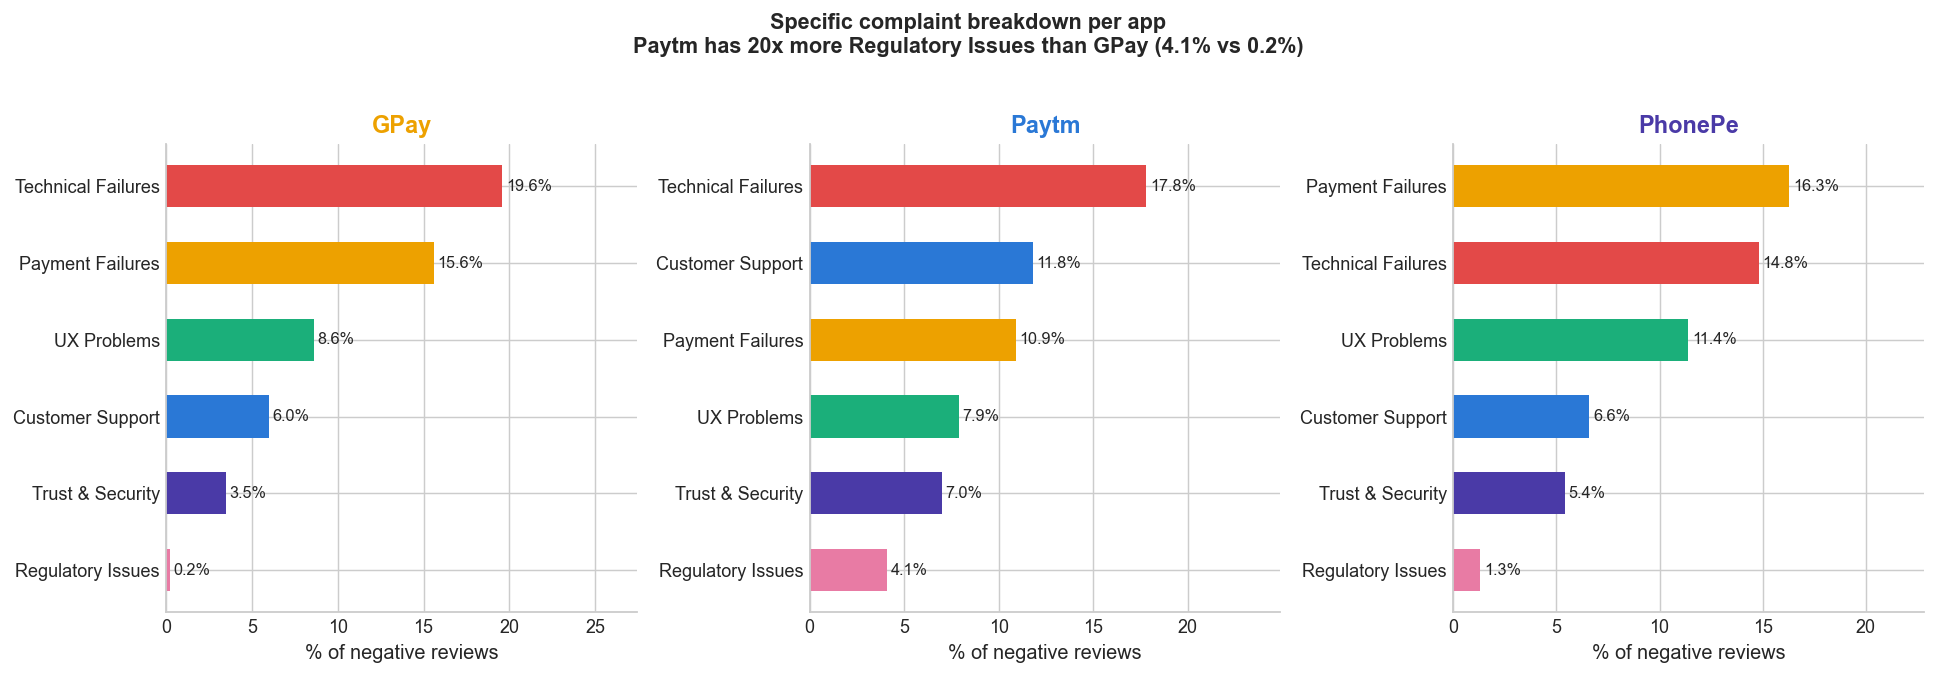

Saved: charts/chart3_complaint_categories.png


In [5]:
q3_specific = q3[q3['complaint_category'] != 'General Dissatisfaction'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, app in zip(axes, ['GPay', 'Paytm', 'PhonePe']):
    df_app = q3_specific[q3_specific['app'] == app].sort_values(
        'pct_of_app_negatives', ascending=True
    )
    bar_colors = [CAT_COLORS.get(c, '#888') for c in df_app['complaint_category']]
    bars = ax.barh(
        df_app['complaint_category'],
        df_app['pct_of_app_negatives'],
        color=bar_colors, height=0.55
    )
    ax.set_title(app, color=APP_COLORS[app], fontsize=13, fontweight='bold')
    ax.set_xlabel('% of negative reviews')
    ax.set_xlim(0, df_app['pct_of_app_negatives'].max() * 1.4)
    for bar, val in zip(bars, df_app['pct_of_app_negatives']):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9
        )

fig.suptitle(
    'Specific complaint breakdown per app\n'
    'Paytm has 20x more Regulatory Issues than GPay (4.1% vs 0.2%)',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('charts/chart3_complaint_categories.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: charts/chart3_complaint_categories.png')

## Step 6 - Chart 4: Paytm Monthly Deep Dive
**From:** Q4  
**Chart:** Stacked area - volume + composition over time  
**Insight:** 1,249% spike in Paytm negative reviews Jan to Jun 2023


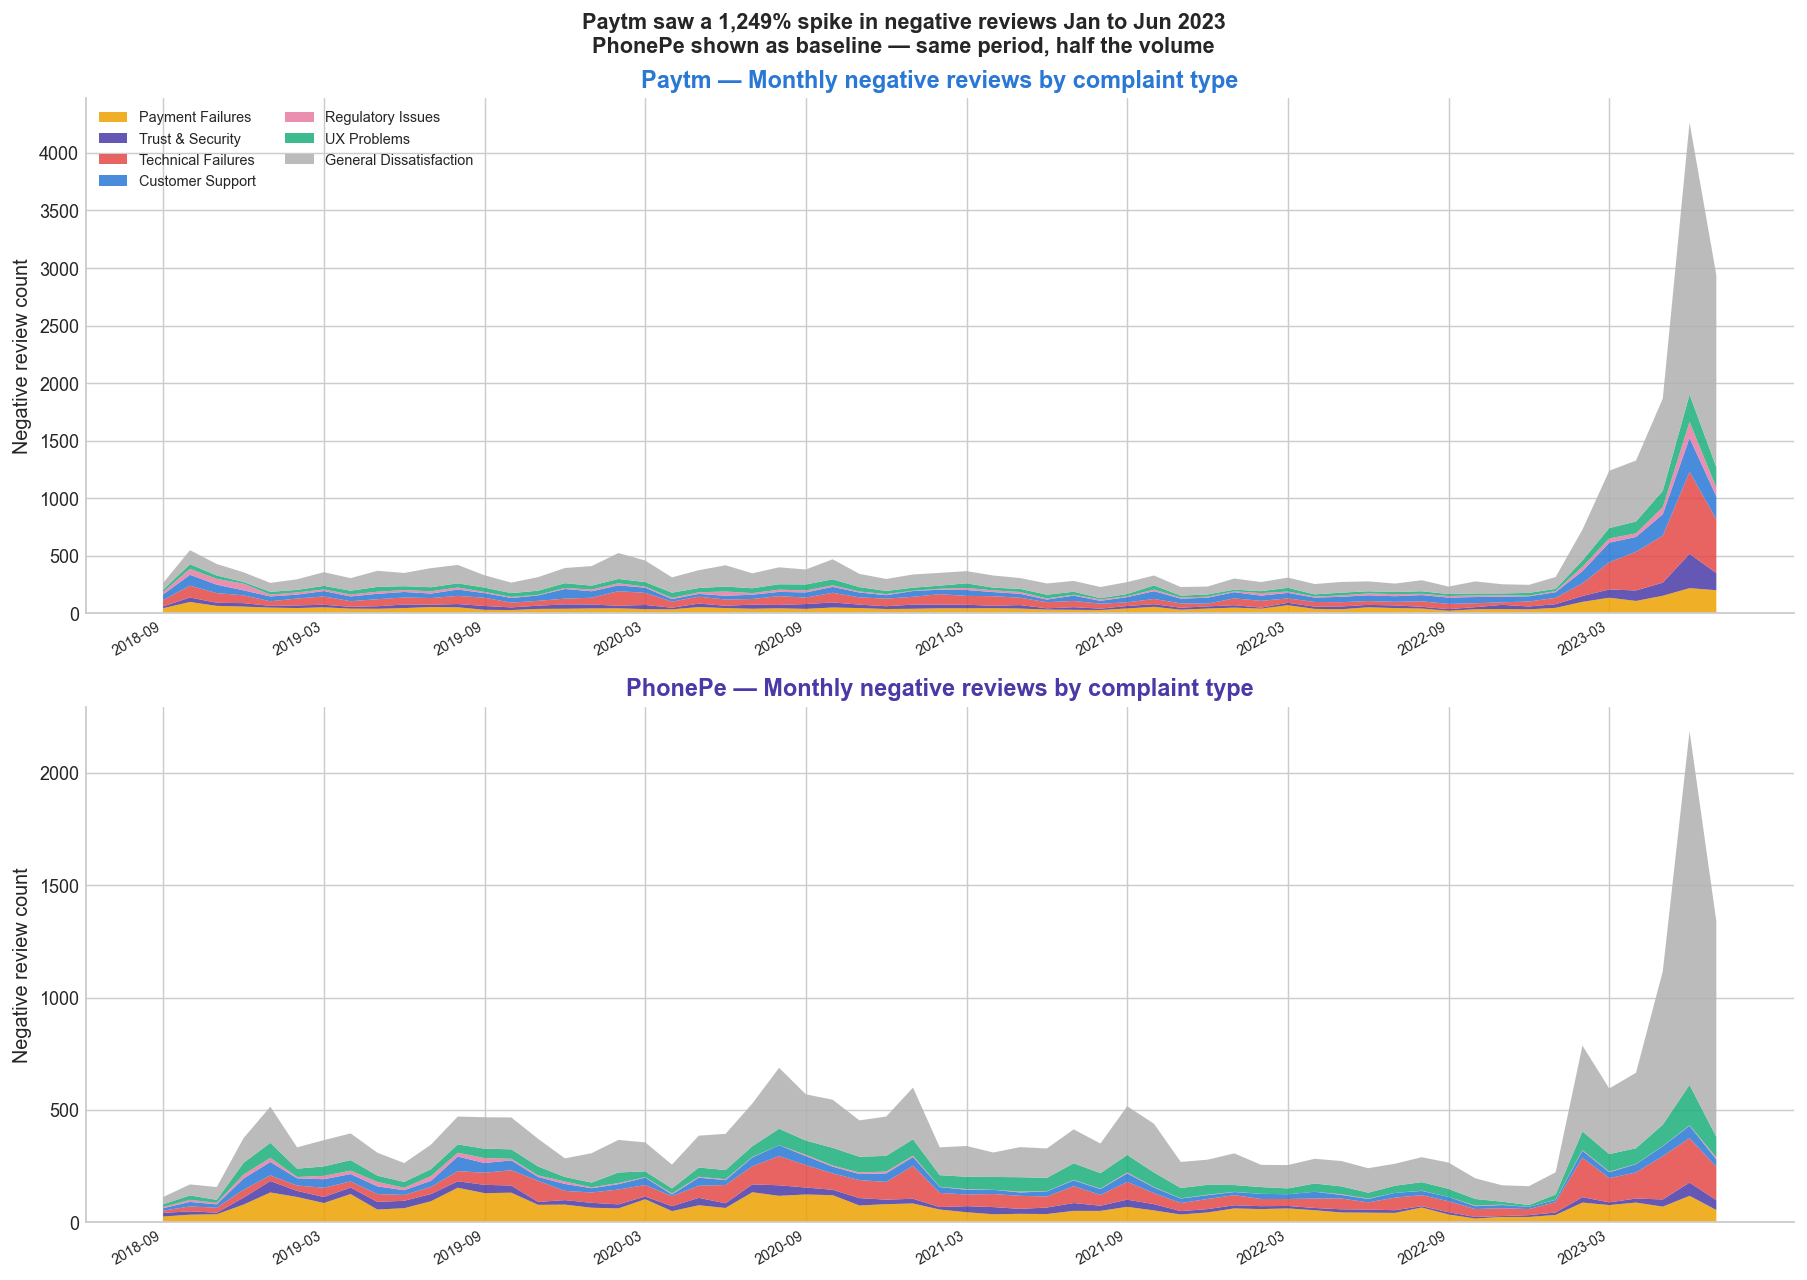

Saved: charts/chart4_paytm_monthly.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

cats = [
    'payment_failures', 'trust_security', 'technical_failures',
    'customer_support', 'regulatory_issues', 'ux_problems', 'other_complaints'
]
cat_labels = [
    'Payment Failures', 'Trust & Security', 'Technical Failures',
    'Customer Support', 'Regulatory Issues', 'UX Problems',
    'General Dissatisfaction'
]
colors_stack = [CAT_COLORS.get(l, '#ccc') for l in cat_labels]

for ax, app in zip(axes, ['Paytm', 'PhonePe']):
    df_app = q4[
        (q4['app'] == app) &
        (~q4['year_month'].str.startswith('2026'))
    ].copy()

    ax.stackplot(
        df_app['year_month'],
        [df_app[c] for c in cats],
        labels=cat_labels,
        colors=colors_stack,
        alpha=0.85
    )
    ax.set_title(
        f'{app} — Monthly negative reviews by complaint type',
        color=APP_COLORS[app], fontweight='bold'
    )
    ax.set_ylabel('Negative review count')

    tick_positions = list(range(0, len(df_app), 6))
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        df_app['year_month'].iloc[tick_positions],
        rotation=30, ha='right', fontsize=8
    )
    if app == 'Paytm':
        ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.9)

fig.suptitle(
    'Paytm saw a 1,249% spike in negative reviews Jan to Jun 2023\n'
    'PhonePe shown as baseline — same period, half the volume',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('charts/chart4_paytm_monthly.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: charts/chart4_paytm_monthly.png')

## Step 7 - Chart 5: Company Response Analysis
**From:** Q5a and Q5b  
**Chart:** Bar (overall rate) + Line (rate over time)  
**Insight:** Paytm responds most (75.9%), GPay collapsed in 2023


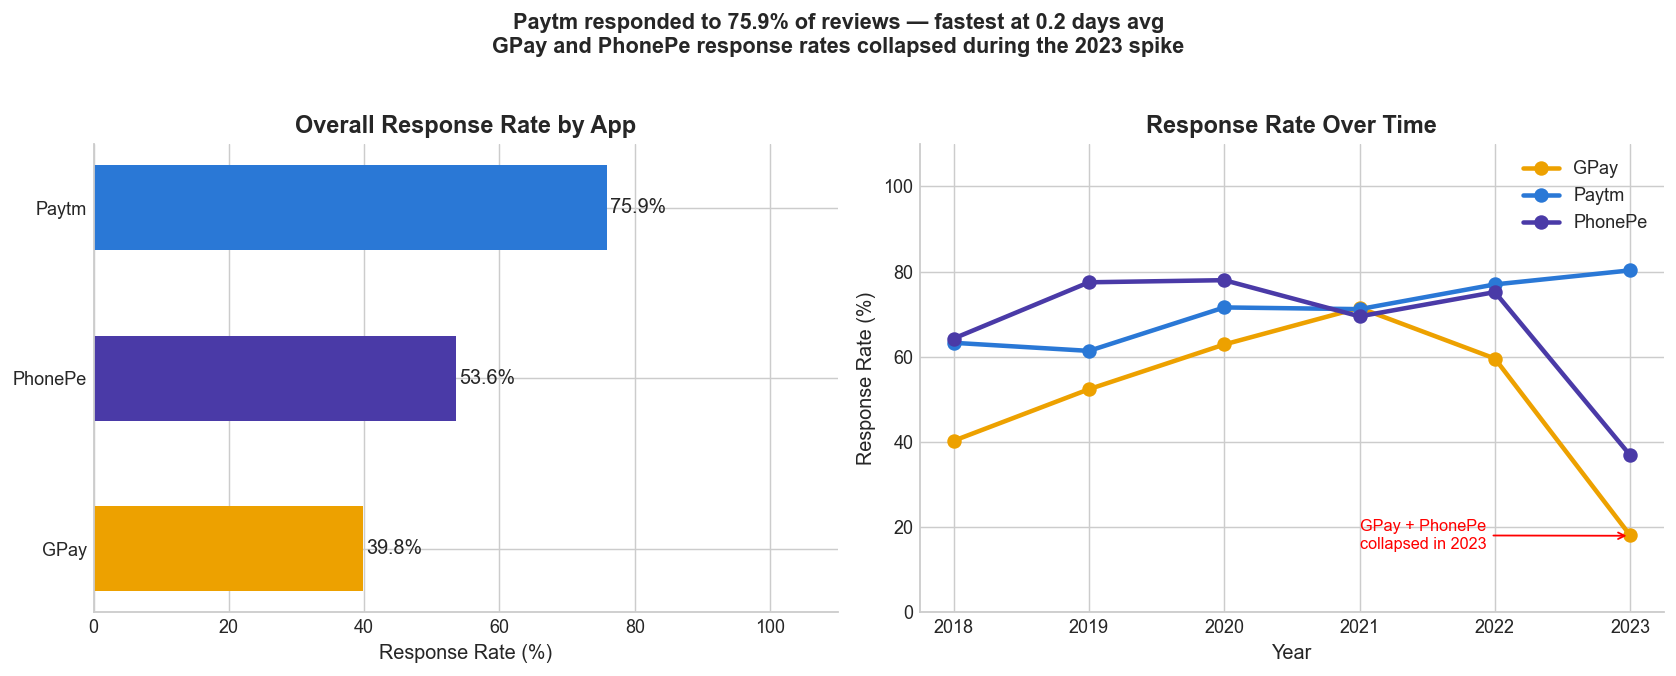

Saved: charts/chart5_response_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — overall response rate
q5a_sorted = q5a.sort_values('response_rate_pct', ascending=True)
colors_resp = [APP_COLORS[a] for a in q5a_sorted['app']]
bars = axes[0].barh(
    q5a_sorted['app'], q5a_sorted['response_rate_pct'],
    color=colors_resp, height=0.5
)
axes[0].set_xlabel('Response Rate (%)')
axes[0].set_xlim(0, 110)
axes[0].set_title('Overall Response Rate by App')
for bar, val in zip(bars, q5a_sorted['response_rate_pct']):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%', va='center', fontsize=11
    )

# Right — response rate by year
for app in ['GPay', 'Paytm', 'PhonePe']:
    df_app = q5b[q5b['app'] == app].sort_values('year')
    axes[1].plot(
        df_app['year'], df_app['response_rate_pct'],
        marker='o', linewidth=2.5, markersize=7,
        color=APP_COLORS[app], label=app
    )

axes[1].set_xlabel('Year')
axes[1].set_ylabel('Response Rate (%)')
axes[1].set_ylim(0, 110)
axes[1].set_title('Response Rate Over Time')
axes[1].legend()
axes[1].annotate(
    'GPay + PhonePe\ncollapsed in 2023',
    xy=(2023, 18), xytext=(2021, 15),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red'
)

fig.suptitle(
    'Paytm responded to 75.9% of reviews — fastest at 0.2 days avg\n'
    'GPay and PhonePe response rates collapsed during the 2023 spike',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('charts/chart5_response_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: charts/chart5_response_analysis.png')

## Step 8 - Chart 6: Era Comparison Heatmap
**From:** Q6b  
**Chart:** Heatmap - complaint % across eras per app  
**Insight:** Payment failures fell over time, Technical failures persisted  
**Note:** General Dissatisfaction shown as a named category with footnote


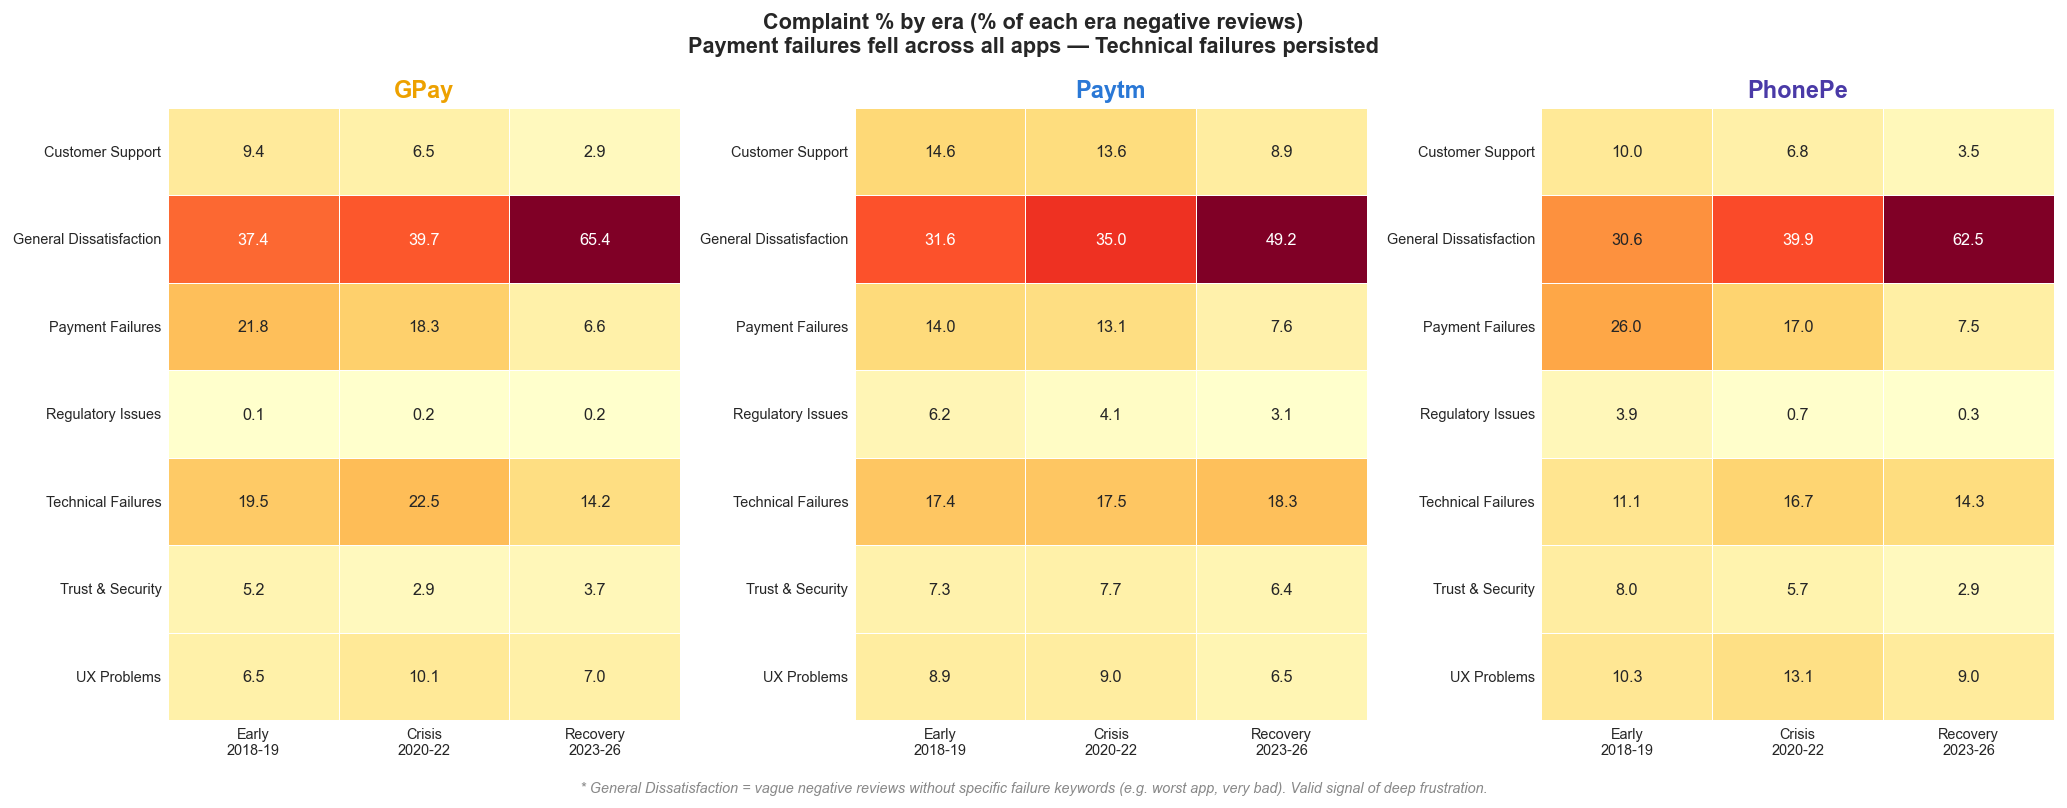

Saved: charts/chart6_era_heatmap.png


In [8]:
q6b['era_label'] = q6b['era'].map(ERA_LABELS)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, app in zip(axes, ['GPay', 'Paytm', 'PhonePe']):
    df_app = q6b[q6b['app'] == app].copy()

    pivot = df_app.pivot(
        index='complaint_category',
        columns='era_label',
        values='pct_of_era_negatives'
    ).fillna(0)

    col_order = ['Early\n2018-19', 'Crisis\n2020-22', 'Recovery\n2023-26']
    col_order = [c for c in col_order if c in pivot.columns]
    pivot = pivot.reindex(columns=col_order)

    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt='.1f',
        cmap='YlOrRd',
        linewidths=0.5,
        cbar=False,
        annot_kws={'size': 9}
    )
    ax.set_title(app, color=APP_COLORS[app], fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle(
    'Complaint % by era (% of each era negative reviews)\n'
    'Payment failures fell across all apps — Technical failures persisted',
    fontsize=12, fontweight='bold'
)
fig.text(
    0.5, -0.02,
    '* General Dissatisfaction = vague negative reviews without specific failure keywords '
    '(e.g. worst app, very bad). Valid signal of deep frustration.',
    ha='center', fontsize=8, color='#888', style='italic'
)
plt.tight_layout()
plt.savefig('charts/chart6_era_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: charts/chart6_era_heatmap.png')

## Step 9 - Chart 7: Executive Summary
**From:** Q6c  
**Chart:** Annotated 3x3 grid - one cell per app per era  
**Insight:** Complete decline story in one view - no Other anywhere


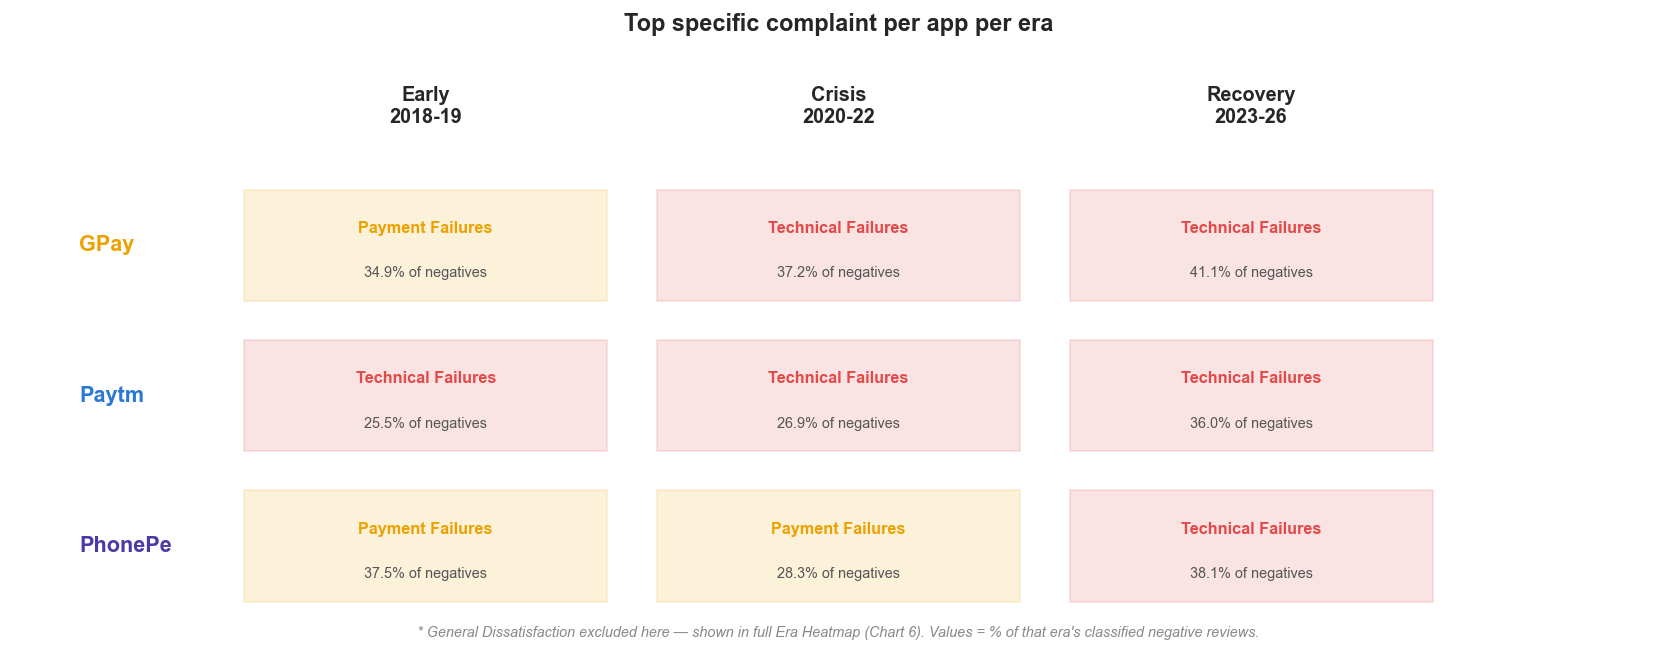

Saved: charts/chart7_executive_summary.png


In [9]:
q6c['era_label'] = q6c['era'].map(ERA_LABELS)

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

apps = ['GPay', 'Paytm', 'PhonePe']
eras = ['Early\n2018-19', 'Crisis\n2020-22', 'Recovery\n2023-26']

# Column headers
for j, era in enumerate(eras):
    ax.text(
        0.25 + j * 0.25, 0.93, era,
        ha='center', va='center',
        fontsize=11, fontweight='bold',
        transform=ax.transAxes
    )

# Rows
for i, app in enumerate(apps):
    y = 0.68 - i * 0.27
    ax.text(
        0.04, y, app,
        ha='left', va='center',
        fontsize=12, fontweight='bold',
        color=APP_COLORS[app],
        transform=ax.transAxes
    )
    for j, era in enumerate(eras):
        x = 0.25 + j * 0.25
        row = q6c[(q6c['app'] == app) & (q6c['era_label'] == era)]
        if len(row) > 0:
            complaint = row['top_complaint'].values[0]
            pct       = row['pct_of_negatives'].values[0]
            color     = CAT_COLORS.get(complaint, '#888')
            rect = plt.Rectangle(
                (x - 0.11, y - 0.10), 0.22, 0.20,
                transform=ax.transAxes,
                color=color, alpha=0.15, clip_on=False
            )
            ax.add_patch(rect)
            ax.text(
                x, y + 0.03, complaint,
                ha='center', va='center',
                fontsize=9, fontweight='bold',
                color=color,
                transform=ax.transAxes
            )
            ax.text(
                x, y - 0.05, f'{pct:.1f}% of negatives',
                ha='center', va='center',
                fontsize=8, color='#555',
                transform=ax.transAxes
            )

ax.set_title(
    'Top specific complaint per app per era',
    fontsize=13, fontweight='bold', pad=20
)
fig.text(
    0.5, 0.01,
    '* General Dissatisfaction excluded here — shown in full Era Heatmap (Chart 6). '
    'Values = % of that era\'s classified negative reviews.',
    ha='center', fontsize=8, color='#888', style='italic'
)
plt.tight_layout()
plt.savefig('charts/chart7_executive_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: charts/chart7_executive_summary.png')

## Step 10 — Export Tableau-Ready CSVs

| File | Tableau Sheet |
|---|---|
| tableau_ratings.csv | Bar chart — avg rating + negative % |
| tableau_trend.csv | Line chart — rating over time |
| tableau_complaints.csv | Grouped bar — complaint categories |
| tableau_monthly.csv | Area chart — Paytm monthly spike |
| tableau_response.csv | Bar + line — response rate |
| tableau_era.csv | Heatmap — complaint shift across eras |
| tableau_summary.csv | Text table — executive summary |


In [12]:
exports = {
    'tableau_ratings.csv':    q1,
    'tableau_trend.csv':      q2,
    'tableau_complaints.csv': q3,
    'tableau_monthly.csv':    q4,
    'tableau_response_a.csv': q5a,
    'tableau_response_b.csv': q5b,
    'tableau_era.csv':        q6b,
    'tableau_summary.csv':    q6c,
}

print('=== TABLEAU EXPORTS ===')
print()
for filename, df in exports.items():
    path = f'tableau_exports/{filename}'
    df.to_csv(path, index=False)
    size = os.path.getsize(path) / 1024
    print(f'  {filename:30s}  {len(df):>4} rows  {size:.1f} KB')

print()
print('All Tableau exports saved to tableau_exports/')
print('In Tableau: Connect -> Text File -> select any of the above')

=== TABLEAU EXPORTS ===

  tableau_ratings.csv                3 rows  0.2 KB
  tableau_trend.csv                 21 rows  0.9 KB
  tableau_complaints.csv            21 rows  0.8 KB
  tableau_monthly.csv              120 rows  5.7 KB
  tableau_response_a.csv             3 rows  0.4 KB
  tableau_response_b.csv            18 rows  0.6 KB
  tableau_era.csv                   63 rows  4.7 KB
  tableau_summary.csv                9 rows  0.7 KB

All Tableau exports saved to tableau_exports/
In Tableau: Connect -> Text File -> select any of the above


## Step 11 - Charts Summary

In [11]:
print('=== CHARTS SAVED ===')
print()
chart_files = sorted([f for f in os.listdir('charts') if f.endswith('.png')])
for f in chart_files:
    size = os.path.getsize(f'charts/{f}') / 1024
    print(f'  {f:45s}  {size:.1f} KB')

print()
print(f'Total: {len(chart_files)} charts')
print()
print('Notebook 03 complete.')
print('Next: open Tableau -> Connect -> Text File -> tableau_exports/')

=== CHARTS SAVED ===

  chart1_ratings_overview.png                    70.5 KB
  chart2_rating_trend.png                        90.3 KB
  chart3_complaint_categories.png                99.5 KB
  chart4_paytm_monthly.png                       250.5 KB
  chart5_response_analysis.png                   129.2 KB
  chart6_era_heatmap.png                         131.7 KB
  chart7_executive_summary.png                   81.3 KB

Total: 7 charts

Notebook 03 complete.
Next: open Tableau -> Connect -> Text File -> tableau_exports/


---
## Notebook 03 Complete

| Chart | Key Insight |
|---|---|
| 1 Ratings Overview | GPay worst (56.9% negative), PhonePe best (41.4%) |
| 2 Rating Trend | Crisis 2020-22, recovery 2023 |
| 3 Complaint Categories | Paytm 20x more regulatory complaints than GPay |
| 4 Paytm Monthly | 1,249% spike in negative reviews mid-2023 |
| 5 Response Analysis | Paytm responds most, GPay least |
| 6 Era Heatmap | Payment failures fell, Technical failures persisted |
| 7 Executive Summary | Clean 3x3 grid — no Other anywhere |

**Proceed to:** Tableau - connect to `tableau_exports/` folder
